In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from utils import concatenate_results_genre, concatenate_results_random, concatenate_results_maetest

In [2]:
path_results = '../results/IRMs'
genre_all = f'{path_results}/1_genre_all.csv'

if not os.path.isfile(genre_all):
    concatenate_results_genre(genre_all, path_results=path_results)

df_genre = pd.read_csv(genre_all)

random_all = f'{path_results}/2_random_all.csv'

if not os.path.isfile(random_all):
    concatenate_results_random(random_all, path_results=path_results)

df_random = pd.read_csv(random_all)

maetest_all = f'{path_results}/3_maetest_all.csv'

if not os.path.isfile(maetest_all):
    concatenate_results_maetest(maetest_all, path_results=path_results)

df_maetest = pd.read_csv(maetest_all)

# extract set of f-score metric columns
columns_fscore = [col for col in df_random.columns if col.startswith('f_')]
# set ordering of genres and models
genres_order = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
models_order = ['OaF', 'Kong', 'T5', 'Toyama', 'Edwards']

markers = {'OaF': 'o', 'Kong': '*', 'T5': 's', 'Toyama': 'D', 'Edwards': '^'} # unused for now.. applying seaborn's default sequence of markers
err_kws_bar = {'alpha': 0.5} #{'color': 'black', 'linewidth': 2.0, 'alpha': 0.5}

# Metrics reported in the respective papers
papers_f1_maestro_test = {
    'f_frame': {
        'OaF': 0.9015, 'Kong': 0.8962, 'T5': None, 'Toyama': 0.9324, 'Edwards': None,},
    'f_note_on': {
        'OaF': 0.9532, 'Kong': 0.9672, 'T5': 0.9601, 'Toyama': 0.9744, 'Edwards': 0.9660,},
    'f_note_on_off': {
        'OaF': 0.8050, 'Kong': 0.8247, 'T5': 0.8394, 'Toyama': 0.9053, 'Edwards': None,},
    'f_note_on_off_vel': {
        'OaF': 0.7754, 'Kong': 0.8092, 'T5': 0.8275, 'Toyama': 0.8948, 'Edwards': None,},
}

df_maetest_papers = pd.DataFrame(papers_f1_maestro_test)
df_maetest_papers.index.name = 'model'
df_maetest_papers.insert(0, 'audioset', 'paper')
df_maetest_papers.reset_index(inplace=True, drop=False)

# our measurements
df_maetest_means = df_maetest.groupby(['model', 'audioset'])[columns_fscore].mean().reset_index()

# combine them
df_maetest_means_all = pd.concat([df_maetest_means, df_maetest_papers])
df_maetest_means_all['model'] = pd.Categorical(df_maetest_means_all['model'], categories=models_order, ordered=True)
df_maetest_means_all.sort_values(['model', 'audioset'], inplace=True)
df_maetest_means_all.reset_index(drop=True, inplace=True)

## Figures

### Figure 6

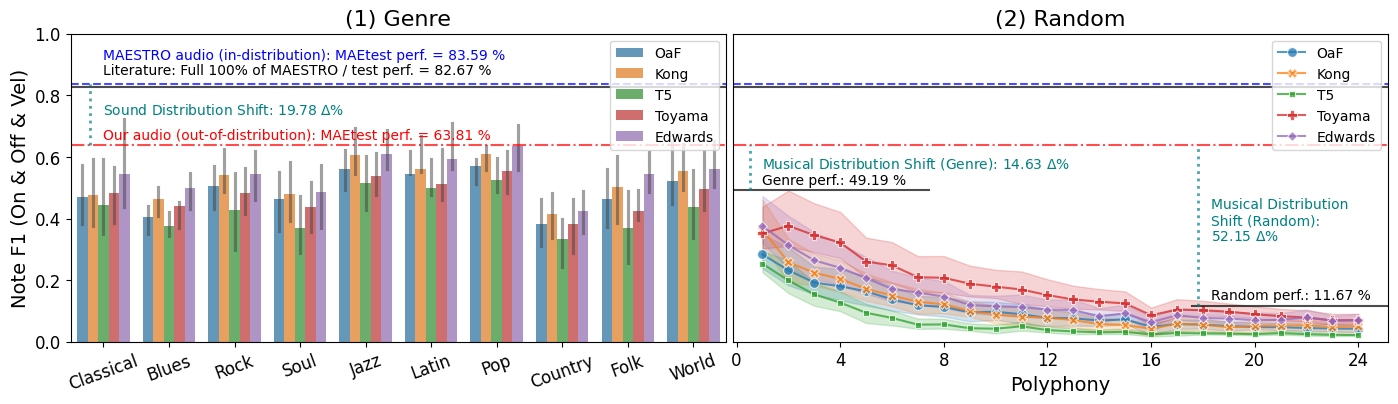

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(16+1, 4), sharey=True, gridspec_kw={'wspace': 0.01})

palette = ['tab10', 'colorblind'][0]
markersize=7 # 6 is the default value
alpha=0.75
fs_title=16
fs_axis=14
fs_ticks=12
rand_ticks = np.arange(0, 25, 4) #[0, 5, 10, 15, 20, 25] #[0, 6, 12, 18, 24]

sns.barplot(ax=axs[0], data=df_genre, x='genre', y='f_note_on_off_vel', hue='model',
            errorbar=('pi', 50), err_kws=err_kws_bar,
            order=genres_order, hue_order=models_order, palette=palette,
            fill=True,
            alpha=alpha
)
axs[0].set_title('(1) Genre', fontsize=fs_title)
axs[0].legend(loc='upper right')
plt.setp(axs[0].get_xticklabels(), rotation=20) # Rotate x tick labels for genres
axs[0].set_ylabel('Note F1 (On & Off & Vel)', fontsize=fs_axis)
axs[0].set_ylim(0.0, 1.0)
axs[0].set_xlabel(None) # hide the "genre" label on x-axis
axs[0].tick_params(axis='x', labelsize=fs_ticks) # set size of x-axis tick labels
axs[0].tick_params(axis='y', labelsize=fs_ticks) # set size of y-axis tick labels

sns.lineplot(ax=axs[1], data=df_random, x='polyphony', y='f_note_on_off_vel', hue='model', style='model',
            markers=True, markersize=markersize, dashes=False, palette=palette,
            errorbar=('pi', 50),
            err_style=['band', 'bars'][0],
            alpha=alpha
)
axs[1].set_title('(2) Random', fontsize=fs_title)
axs[1].legend(loc='upper right')
axs[1].set_xlabel('Polyphony', fontsize=fs_axis)
axs[1].tick_params(left=False) # hide y-axis ticks
axs[1].set_xticks(rand_ticks)
axs[1].tick_params(axis='x', labelsize=fs_ticks) # set size of x-axis tick labels

# Add a horizontal dashed line at SotA performance level
sota_p = df_maetest_means_all[df_maetest_means_all['audioset'] == 'paper']['f_note_on_off_vel'].mean()
sota_m = df_maetest_means_all[df_maetest_means_all['audioset'] == 'maestro']['f_note_on_off_vel'].mean()
sota_d = df_maetest_means_all[df_maetest_means_all['audioset'] == 'disklavier']['f_note_on_off_vel'].mean()
for ax in axs:
    ax.axhline(sota_p, color='black', linestyle='-', alpha=0.7)
    ax.axhline(sota_m, color='blue', linestyle='--', alpha=0.7)
    ax.axhline(sota_d, color='red', linestyle='-.', alpha=0.7)
axs[0].text(0.0, sota_p+0.04, f'Literature: Full 100% of MAESTRO / test perf. = {100*sota_p:.2f} %', color='black')
axs[0].text(0.0, sota_m+0.08, f'MAESTRO audio (in-distribution): MAEtest perf. = {100*sota_m:.2f} %', color='blue')
axs[0].text(0.0, sota_d+0.02, f'Our audio (out-of-distribution): MAEtest perf. = {100*sota_d:.2f} %', color='red')

axs[0].axvline(-0.2, sota_d, sota_m, color='teal', linestyle=':', linewidth=2.0, alpha=0.7)
axs[0].text(0.0, np.mean([sota_d, sota_m]), f'Sound Distribution Shift: {100*(sota_m-sota_d):.2f} $\Delta$%', color='teal')

# add lines on right half-side of the 2nd subplot for the global average performance across all of Genre, and all of Random
perf_g = df_genre['f_note_on_off_vel'].mean()
perf_r = df_random['f_note_on_off_vel'].mean()
# average Genre performance
axs[1].axhline(perf_g, 0.0, 0.3, color='black', linestyle='-', alpha=0.7)
axs[1].text(1.0, perf_g+0.02, f'Genre perf.: {100*perf_g:.2f} %', color='black')
axs[1].axvline(0.5, perf_g, sota_d, color='teal', linestyle=':', linewidth=2.0, alpha=0.7)
axs[1].text(1.0, np.mean([perf_g, sota_d]), f'Musical Distribution Shift (Genre): {100*(sota_d-perf_g):.2f} $\Delta$%', color='teal')
# average Random performance
axs[1].axhline(perf_r, 0.7, 1.0, color='black', linestyle='-', alpha=0.7)
axs[1].text(18.3, perf_r+0.02, f'Random perf.: {100*perf_r:.2f} %', color='black')
axs[1].axvline(17.8, perf_r, sota_d, color='teal', linestyle=':', linewidth=2.0, alpha=0.7)
axs[1].text(18.3, np.mean([perf_r, sota_d])-.05, f'Musical Distribution\nShift (Random):\n{100*(sota_d-perf_r):.2f} $\Delta$%', color='teal')

# fig.savefig('../paper/figs/eval_all_note_on_off_vel.pdf', bbox_inches='tight')
plt.show()

### Figure 7

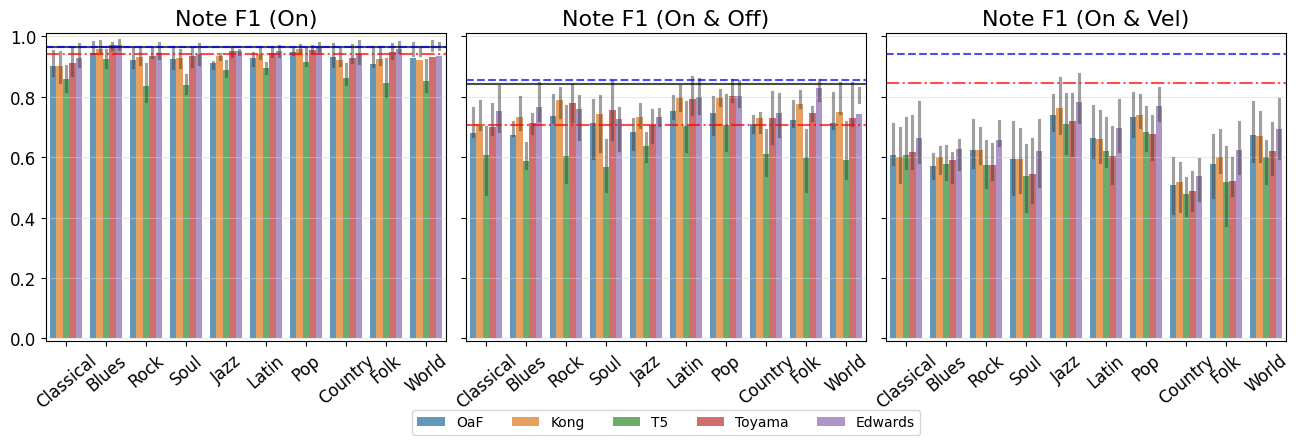

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True, gridspec_kw={'wspace': 0.05})

metrics_titles = {
    'f_frame': 'Frame F1',
    'f_note_on': 'Note F1 (On)',
    'f_note_on_off': 'Note F1 (On & Off)',
    'f_note_on_vel': 'Note F1 (On & Vel)',
    'f_note_on_off_vel': 'Note F1 (On & Off & Vel)',
    }

markersize=7 # 6 is the default value
alpha=0.75
fs_title=16
fs_axis=14
fs_ticks=12

palette = ['tab10', 'colorblind'][0]

# Genre set
for metric, ax in zip(columns_fscore[1:-1], axs):
    sns.barplot(ax=ax, data=df_genre, x='genre', y=metric,
                errorbar=('pi', 50), err_kws=err_kws_bar,
                hue='model', hue_order=models_order, palette=palette,
                # style=True,
                order=genres_order, alpha=alpha)
    ax.set_title(metrics_titles[metric], fontsize=fs_title)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.grid(axis='y', color='lightgrey', alpha=0.5)
    plt.setp(ax.get_xticklabels(), rotation=40) # Rotate x tick labels
    ax.tick_params(axis='x', labelsize=fs_ticks)
    ax.tick_params(axis='y', labelsize=fs_ticks)

    if metric == 'f_note_on_off':
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), title=None, ncol=len(models_order))
    else:
        ax.legend().remove()


    # Add a horizontal dashed line at SotA performance level
    sota_p = df_maetest_means_all[df_maetest_means_all['audioset'] == 'paper'][metric].mean()
    sota_m = df_maetest_means_all[df_maetest_means_all['audioset'] == 'maestro'][metric].mean()
    sota_d = df_maetest_means_all[df_maetest_means_all['audioset'] == 'disklavier'][metric].mean()
    
    ax.axhline(sota_p, color='black', linestyle='-', alpha=0.7)
    ax.axhline(sota_m, color='blue', linestyle='--', alpha=0.7)
    ax.axhline(sota_d, color='red', linestyle='-.', alpha=0.7)

axs[0].set_ylim(-0.01, 1.01)

# fig.savefig('../paper/figs/eval_genre_note_triplet_breakdown.pdf', bbox_inches='tight')
plt.show()

### Figure 11

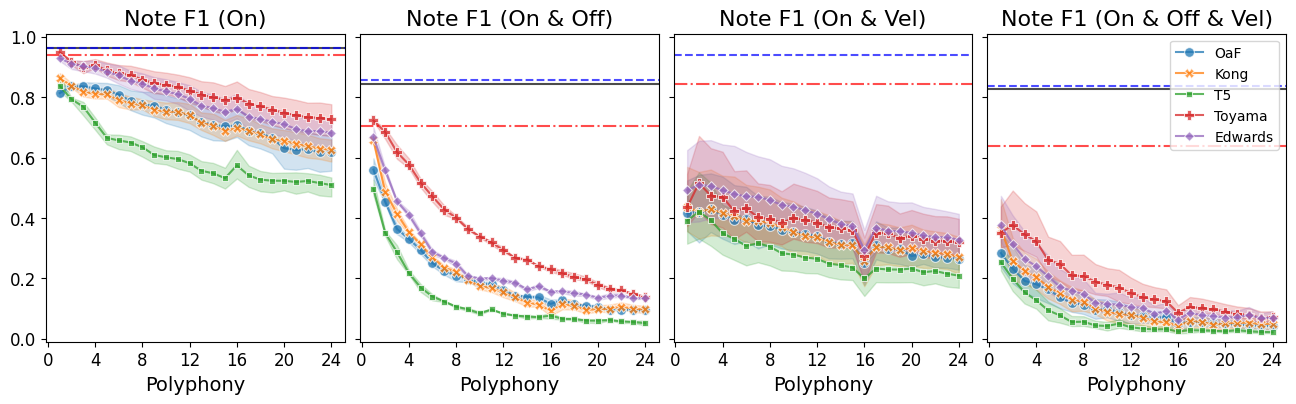

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True, gridspec_kw={'wspace': 0.05})

metrics_titles = {
    'f_frame': 'Frame F1',
    'f_note_on': 'Note F1 (On)',
    'f_note_on_off': 'Note F1 (On & Off)',
    'f_note_on_vel': 'Note F1 (On & Vel)',
    'f_note_on_off_vel': 'Note F1 (On & Off & Vel)',
    }

markersize=7 # 6 is the default value
alpha=0.75
fs_title=16
fs_axis=14
fs_ticks=12
rand_ticks = np.arange(0, 25, 4) #[0, 5, 10, 15, 20, 25] #[0, 6, 12, 18, 24]

for metric, ax in zip(columns_fscore[1:], axs):
    sns.lineplot(data=df_random, x='polyphony', y=metric,
                 hue='model', hue_order=models_order,
                 style='model', style_order=models_order,
                 markers=True, dashes=False, markersize=markersize,
                 marker='*', alpha=alpha, errorbar=('pi', 50),
                 ax=ax)
    ax.set_title(metrics_titles[metric], fontsize=fs_title)
    ax.set_ylabel(None)
    ax.set_xlabel('Polyphony', fontsize=fs_axis)
    ax.set_xticks(rand_ticks)
    ax.tick_params(axis='x', labelsize=fs_ticks)
    ax.tick_params(axis='y', labelsize=fs_ticks)

    if metric == 'f_note_on_off_vel':
        ax.legend(loc='upper right')
    else:
        ax.legend().remove()

    # Add a horizontal dashed line at SotA performance level
    sota_p = df_maetest_means_all[df_maetest_means_all['audioset'] == 'paper'][metric].mean()
    sota_m = df_maetest_means_all[df_maetest_means_all['audioset'] == 'maestro'][metric].mean()
    sota_d = df_maetest_means_all[df_maetest_means_all['audioset'] == 'disklavier'][metric].mean()
    
    ax.axhline(sota_p, color='black', linestyle='-', alpha=0.7)
    ax.axhline(sota_m, color='blue', linestyle='--', alpha=0.7)
    ax.axhline(sota_d, color='red', linestyle='-.', alpha=0.7)

axs[0].set_ylim(-0.01, 1.01)

# fig.savefig('../paper/figs/eval_random_note_all.pdf', bbox_inches='tight')
plt.show()

### Figure 12

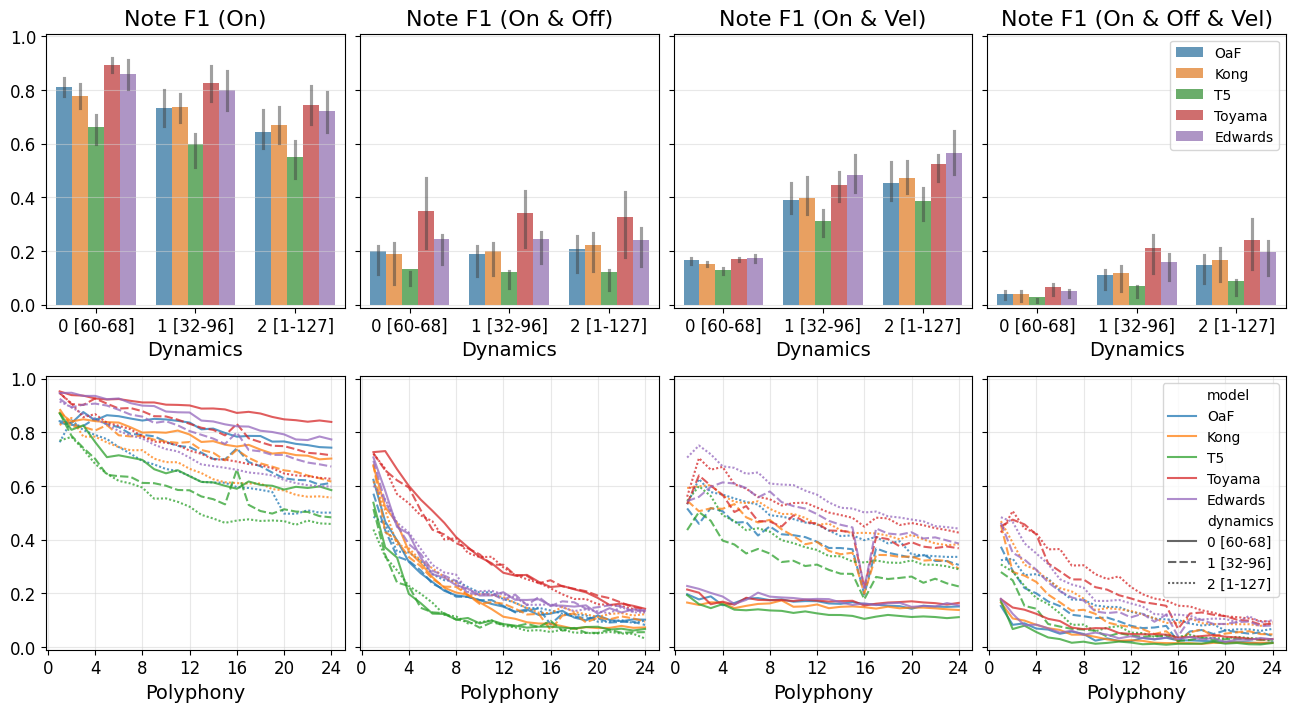

In [6]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8), sharey=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.25})

metrics_titles = {
    'f_frame': 'Frame F1',
    'f_note_on': 'Note F1 (On)',
    'f_note_on_off': 'Note F1 (On & Off)',
    'f_note_on_vel': 'Note F1 (On & Vel)',
    'f_note_on_off_vel': 'Note F1 (On & Off & Vel)',
    }

markersize=7 # 6 is the default value
alpha=0.75
fs_title=16
fs_axis=14
fs_ticks=12
rand_ticks = np.arange(0, 25, 4) #[0, 5, 10, 15, 20, 25] #[0, 6, 12, 18, 24]

# dynamics_labels = {0: 'narrow', 1: 'medium', 2: 'wide'}
dynamics_labels = {0: '0 [60-68]', 1: '1 [32-96]', 2: '2 [1-127]'}

# Random set -- dynamics aggregated breakdown
for metric, ax in zip(columns_fscore[1:], axs[0]):
    sns.barplot(data=df_random, x='dynamics', y=metric,
                errorbar=('pi', 50), err_kws=err_kws_bar,
                hue='model', hue_order=models_order,
                alpha=.75,
                ax=ax)
    ax.set_title(metrics_titles[metric], fontsize=fs_title)
    ax.set_xlabel('Dynamics', fontsize=fs_axis)
    ax.set_ylabel(None)
    ax.grid(axis='y', color='lightgrey', alpha=0.5)
    # Remap x-axis tick labels
    ax.set_xticklabels([dynamics_labels[int(tick.get_text())] for tick in ax.get_xticklabels()])
    ax.tick_params(axis='x', labelsize=fs_ticks)
    ax.tick_params(axis='y', labelsize=fs_ticks)
    if metric == 'f_note_on_off_vel':
        ax.legend(loc='upper right')
    else:
        ax.legend().remove()

# Random set -- dynamics detailed breakdown
for metric, ax in zip(columns_fscore[1:], axs[1]):
    sns.lineplot(data=df_random, x='polyphony', y=metric,
                 hue='model', hue_order=models_order,
                 style='dynamics', markers=False, dashes=True,
                 alpha=.75,
                 ax=ax)
    ax.set_title(None)
    ax.set_xlabel('Polyphony', fontsize=fs_axis)
    ax.set_ylabel(None)
    # set x tick frequency to show each 4-th tick
    ax.set_xticks(rand_ticks)
    # introduce light grey grid lines (alpha=0.5) based on where ticks are on both axes
    ax.grid(axis='both', color='lightgrey', alpha=0.5)
    ax.tick_params(axis='x', labelsize=fs_ticks)
    ax.tick_params(axis='y', labelsize=fs_ticks)
    if metric == 'f_note_on_off_vel':
        ax.legend(loc='upper right')
    else:
        ax.legend().remove()
    # Remap dynamics legend entries
    legend = ax.get_legend()
    if legend:
        for text in legend.get_texts():
            # print(text.get_text(), text.get_text().isdigit())
            if text.get_text().isdigit():  # Check if the legend entry is a number
                text.set_text(dynamics_labels[int(text.get_text())])  # Map using the dictionary


axs[0][0].set_ylim(-0.01, 1.01)

# fig.savefig('../paper/figs/eval_random_note_dyn_breakdown.pdf', bbox_inches='tight')
plt.show()

# END